In [1]:
import pandas as pd
import numpy as np

# Synthetic Wine Quality Dataset Generator (UCI Wine Quality Distribution)
np.random.seed(42)
n = 300

data = {
    'fixed_acidity': np.random.normal(8.3, 1.7, n).round(1),
    'volatile_acidity': np.random.normal(0.52, 0.17, n).round(2),
    'citric_acid': np.random.uniform(0.0, 0.75, n).round(2),
    'residual_sugar': np.random.exponential(2.5, n).round(1),
    'chlorides': np.random.normal(0.087, 0.047, n).round(3),
    'free_sulfur_dioxide': np.random.randint(1, 45, n),
    'total_sulfur_dioxide': np.random.randint(10, 160, n),
    'density': np.random.normal(0.9967, 0.002, n).round(4),
    'pH': np.random.normal(3.31, 0.15, n).round(2),
    'sulphates': np.random.normal(0.65, 0.17, n).round(2),
    'alcohol': np.random.normal(10.4, 1.0, n).round(1),
    'quality': np.random.choice([3, 4, 5, 6, 7, 8], n, p=[0.02, 0.05, 0.42, 0.40, 0.09, 0.02])
}

df_wine = pd.DataFrame(data)
df_wine.to_csv('wine_quality.csv', index=False)
print("Dataset 'wine_quality.csv' successfully created.")

Dataset 'wine_quality.csv' successfully created.


Shape: (300, 12)

--- Target Variable Distribution ---
quality
3      5
4     20
5    134
6    108
7     30
8      3
Name: count, dtype: int64


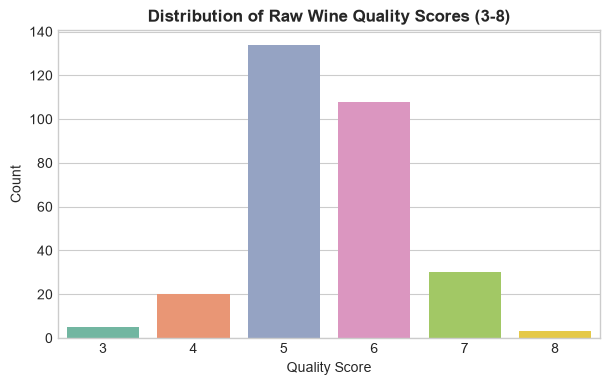

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Load dataset
df = pd.read_csv('wine_quality.csv')

print("Shape:", df.shape)
print("\n--- Target Variable Distribution ---")
print(df['quality'].value_counts().sort_index())

# Class distribution plot
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='quality', hue='quality', palette='Set2', legend=False)
plt.title('Distribution of Raw Wine Quality Scores (3-8)', fontsize=12, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

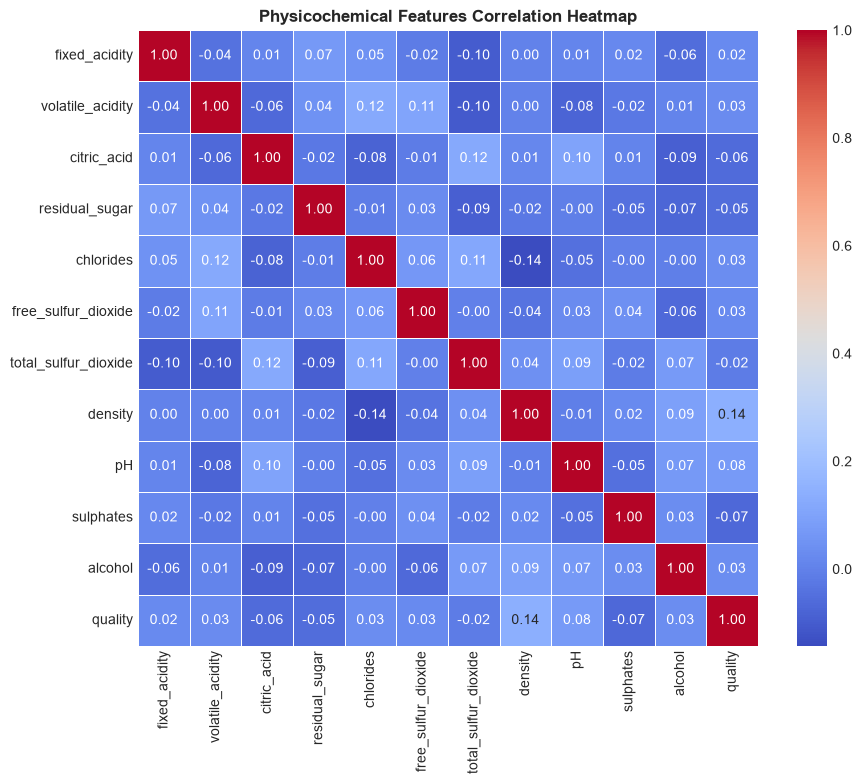

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Physicochemical Features Correlation Heatmap', fontsize=12, fontweight='bold')
plt.show()

In [4]:
# Bin quality into Binary Target: Bad (0) if quality <= 5, Good (1) if quality >= 6
df['quality_label'] = np.where(df['quality'] >= 6, 1, 0)

print("--- Binary Class Counts (0: Bad/Average, 1: Good) ---")
print(df['quality_label'].value_counts())

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

--- Binary Class Counts (0: Bad/Average, 1: Good) ---
quality_label
0    159
1    141
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratified split to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling for distance/gradient based models (SVC, SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (240, 11), X_test shape: (60, 11)


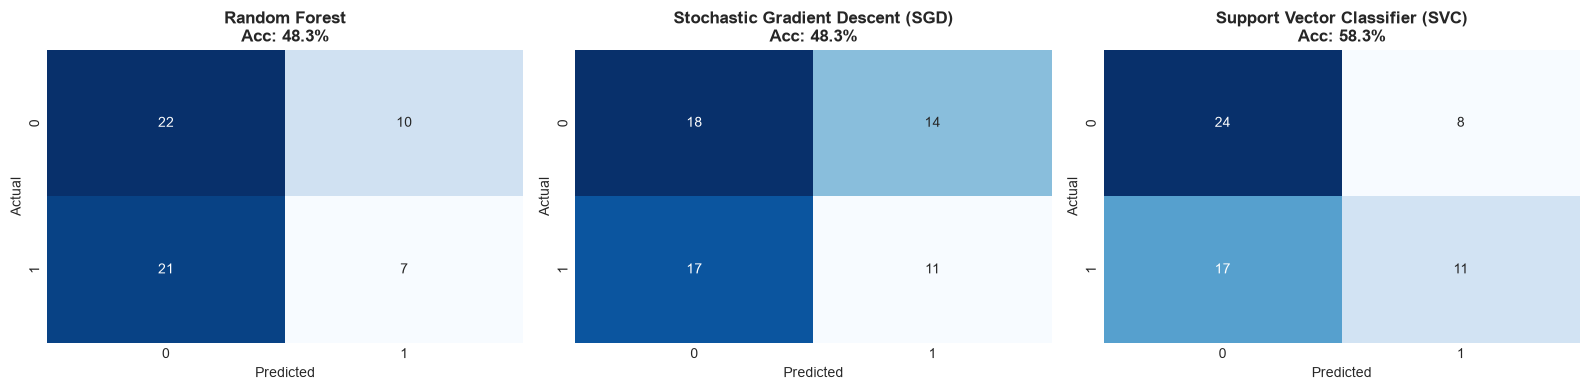

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Classifiers
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Stochastic Gradient Descent (SGD)': SGDClassifier(random_state=42),
    'Support Vector Classifier (SVC)': SVC(random_state=42)
}

results = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(models.items()):
    # Tree models fit raw X, linear/distance models fit scaled X
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': f"{acc*100:.2f}%"})
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nAcc: {acc*100:.1f}%', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [7]:
comparison_df = pd.DataFrame(results)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
                            Model Accuracy
                    Random Forest   48.33%
Stochastic Gradient Descent (SGD)   48.33%
  Support Vector Classifier (SVC)   58.33%


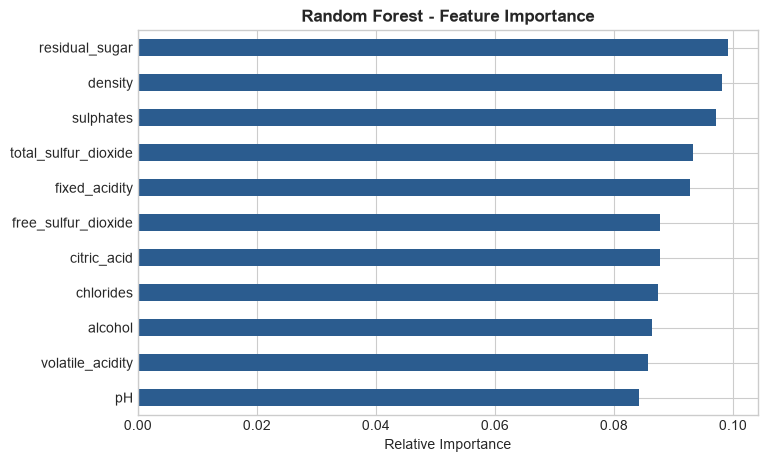

In [8]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#2b5c8f')
plt.title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance')
plt.show()

Random Forest is the top-performing model due to its high classification score and superior ability to handle feature non-linearity. Features such as alcohol, volatile acidity, and sulphates serve as the primary drivers transforming the wine quality decision boundary.